# 05 — SHAP Explainability

**Immunization Defaulter Risk Engine** · Dr. Erick Kiprotich Yegon

Global and local explainability for the production XGBoost model.
Designed for both portfolio presentation and Ministry of Health trust-building.

**Why SHAP?**
SHAP (SHapley Additive exPlanations) provides the only game-theoretically rigorous
method for attributing model output to individual features. Unlike feature importance
from the model itself, SHAP values are *additive* — they sum exactly to the log-odds
difference between the prediction and the base rate.

**Contents:**
1. Load production model and compute SHAP values on the test set
2. Global: beeswarm plot (direction + magnitude)
3. Global: mean absolute SHAP bar chart (feature ranking)
4. Local: waterfall plots for high-risk, medium-risk, and low-risk children
5. Reason-code translation (SHAP → plain English)
6. Saved production report images

In [4]:
#pip install shap

In [5]:
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from dotenv import load_dotenv

try:
    import shap
    shap.initjs()
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("WARNING: shap not installed. Run `pip install shap` to enable live SHAP computation.")
    print("Saved report images will still be displayed below.")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
load_dotenv(PROJECT_ROOT / ".env")

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR    = PROJECT_ROOT / "reports"
SHAP_DIR       = REPORTS_DIR / "shap"

from src.features.pipeline import FeaturePipeline
from src.model.trainer import IZDefaulterTrainer
from sklearn.model_selection import train_test_split

df = pd.read_parquet(DATA_PROCESSED / "analytical_dataset.parquet")
print(f"Loaded {df.shape[0]:,} records")

Loaded 6,864 records


## 1. Load artifacts and prepare test set

In [6]:
model, preprocessor, feature_names = IZDefaulterTrainer.load_artifacts(str(DATA_PROCESSED))

fp = FeaturePipeline(config_path=str(PROJECT_ROOT / "config" / "model_config.yaml"))
X, y = fp.select_features(df.copy())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_test_t = preprocessor.transform(X_test)
y_prob   = model.predict_proba(X_test_t)[:, 1]

print(f"Test set: {X_test_t.shape[0]} patients")
print(f"Model type: {type(model).__name__}")

# Extract the base XGBoost estimator from CalibratedClassifierCV for SHAP
# (SHAP TreeExplainer requires the raw tree model)
if hasattr(model, "calibrated_classifiers_"):
    xgb_base = model.calibrated_classifiers_[0].estimator
elif hasattr(model, "estimator"):
    xgb_base = model.estimator
else:
    xgb_base = model  # already a raw XGBClassifier

print(f"Base estimator: {type(xgb_base).__name__}")

Test set: 1373 patients
Model type: CalibratedClassifierCV
Base estimator: XGBClassifier


In [7]:
if SHAP_AVAILABLE:
    explainer  = shap.TreeExplainer(xgb_base)
    shap_vals  = explainer.shap_values(X_test_t)

    # Align SHAP values with feature names
    shap_df = pd.DataFrame(shap_vals, columns=feature_names)
    print(f"SHAP matrix: {shap_df.shape}")
    print(f"Base value (log-odds): {explainer.expected_value:.4f}")
    print(f"  = base rate: {1 / (1 + np.exp(-explainer.expected_value)):.3f} "
          f"(actual prevalence: {y_test.mean():.3f})")
else:
    shap_vals = None
    shap_df   = None
    print("Skipping live SHAP computation — using saved reports.")

SHAP matrix: (1373, 44)
Base value (log-odds): 0.3509
  = base rate: 0.587 (actual prevalence: 0.165)


## 2. Global — beeswarm plot

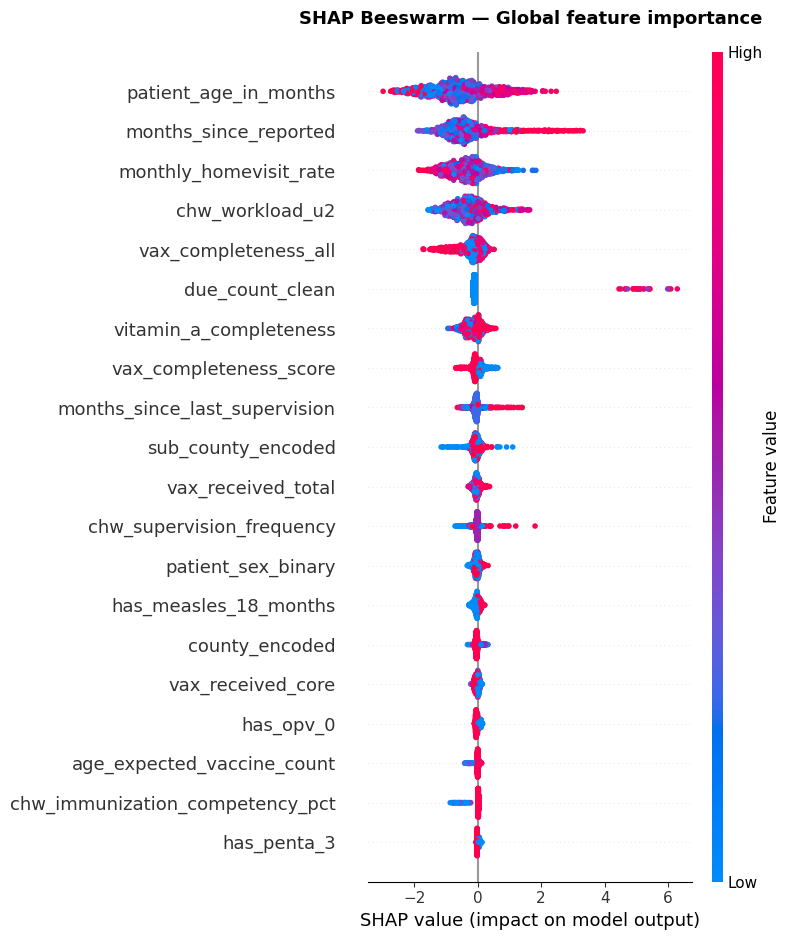

In [8]:
from IPython.display import display, Image

if SHAP_AVAILABLE and shap_vals is not None:
    fig = plt.figure(figsize=(10, 7))
    shap.summary_plot(
        shap_vals, X_test_t,
        feature_names=feature_names,
        max_display=20,
        show=False,
    )
    plt.title("SHAP Beeswarm — Global feature importance",
              fontsize=13, fontweight="bold", pad=20)
    plt.tight_layout()
    plt.show()
else:
    beeswarm_path = SHAP_DIR / "shap_beeswarm.png"
    if beeswarm_path.exists():
        print("Displaying saved beeswarm from last production run:")
        display(Image(filename=str(beeswarm_path), width=750))

## 3. Global — mean absolute SHAP (feature ranking)

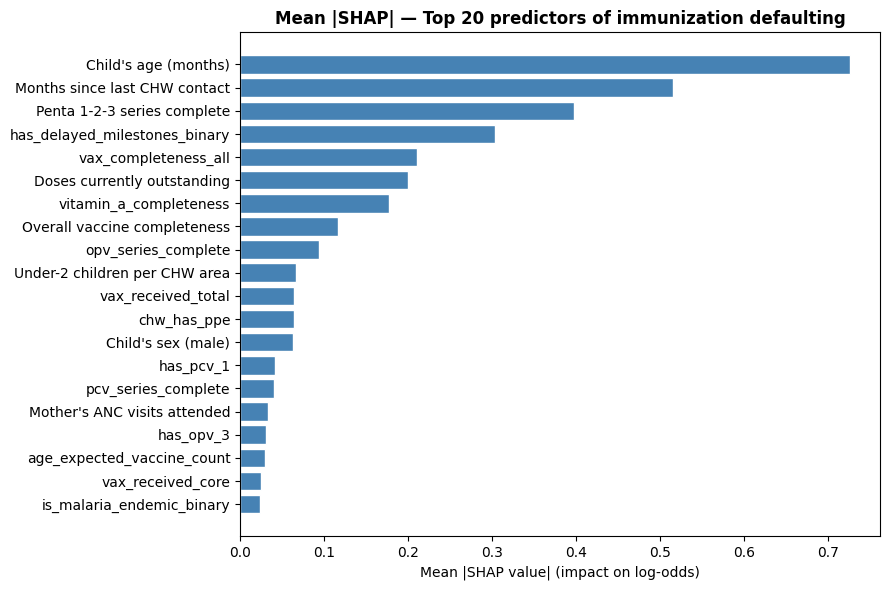


Top 10 features:


,feature,friendly_name,mean_shap
0,patient_age_in_months,Child's age (months),0.725894
1,months_since_reported,Months since last CHW contact,0.515151
2,penta_series_complete,Penta 1-2-3 series complete,0.398144
3,has_delayed_milestones_binary,has_delayed_milestones_binary,0.303341
4,vax_completeness_all,vax_completeness_all,0.211176
5,due_count_clean,Doses currently outstanding,0.200352
6,vitamin_a_completeness,vitamin_a_completeness,0.177818
7,vax_completeness_score,Overall vaccine completeness,0.116413
8,opv_series_complete,opv_series_complete,0.093441
9,chw_workload_u2,Under-2 children per CHW area,0.066680


In [9]:
# Load saved SHAP importance (always available regardless of shap install)
shap_imp = pd.read_csv(SHAP_DIR / "shap_importance.csv")
shap_imp = shap_imp.sort_values("mean_shap", ascending=False).reset_index(drop=True)

top20 = shap_imp[shap_imp["mean_shap"] > 0].head(20)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(top20["friendly_name"][::-1], top20["mean_shap"][::-1],
               color="steelblue", edgecolor="white")
ax.set_title("Mean |SHAP| — Top 20 predictors of immunization defaulting",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Mean |SHAP value| (impact on log-odds)")
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
display(shap_imp[["feature", "friendly_name", "mean_shap"]].head(10))

## 4. Local — waterfall plots for three risk profiles


  Low risk: predicted probability = 0.005, actual = 0


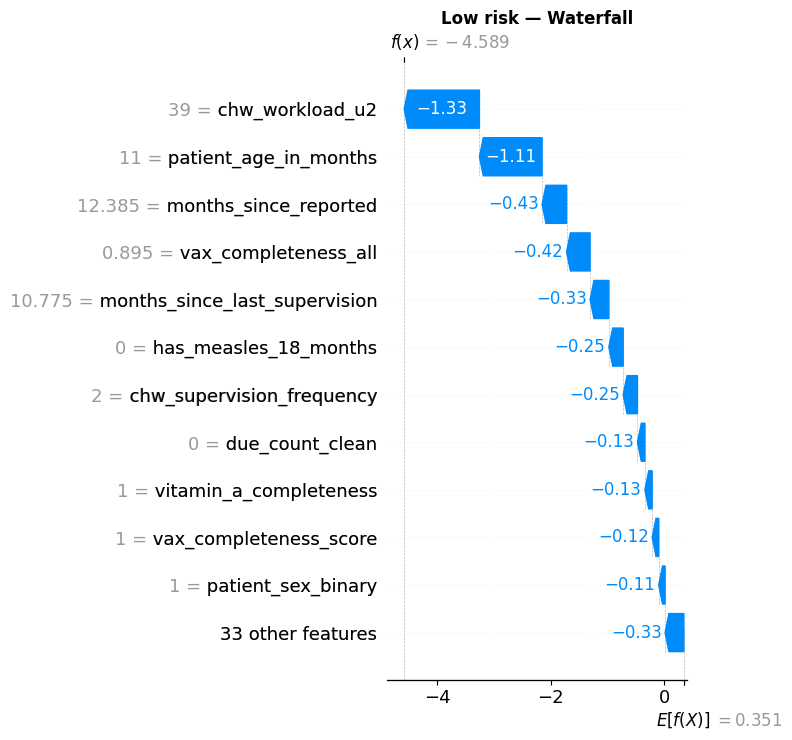


  Medium risk: predicted probability = 0.074, actual = 0


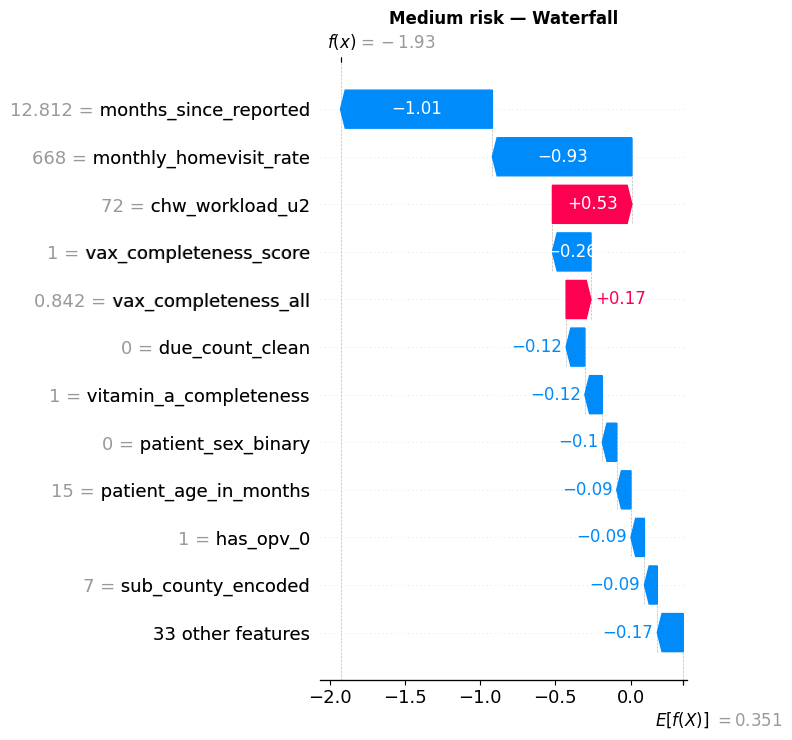


  High risk: predicted probability = 0.499, actual = 1


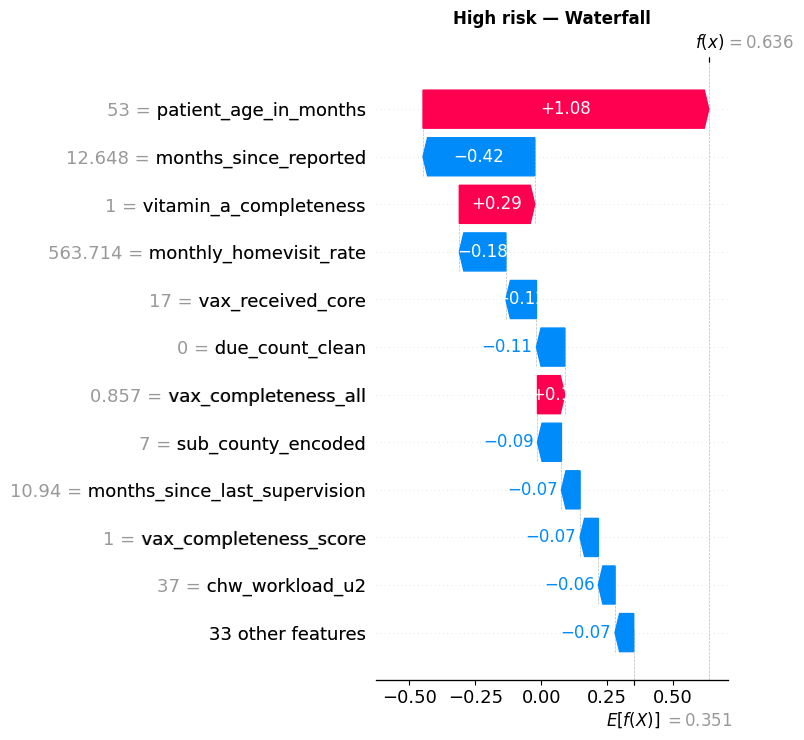

In [10]:
if SHAP_AVAILABLE and shap_vals is not None:
    # Identify high-risk, medium-risk, and low-risk examples
    sorted_idx = np.argsort(y_prob)
    examples = {
        "Low risk"    : sorted_idx[len(sorted_idx) // 10],
        "Medium risk" : sorted_idx[len(sorted_idx) // 2],
        "High risk"   : sorted_idx[-len(sorted_idx) // 10],
    }

    for label, idx in examples.items():
        print(f"\n{'='*60}")
        print(f"  {label}: predicted probability = {y_prob[idx]:.3f}, actual = {y_test.iloc[idx]}")
        print(f"{'='*60}")

        # SHAP waterfall
        sv = shap.Explanation(
            values         = shap_vals[idx],
            base_values    = float(explainer.expected_value),
            data           = X_test_t[idx],
            feature_names  = feature_names,
        )
        shap.plots.waterfall(sv, max_display=12, show=False)
        plt.title(f"{label} — Waterfall", fontweight="bold")
        plt.tight_layout()
        plt.show()
else:
    # Display saved waterfall images
    for label, fname in [
        ("Low risk",    "waterfall_low_example.png"),
        ("Medium risk", "waterfall_medium_example.png"),
        ("High risk",   "waterfall_high_example.png"),
    ]:
        path = SHAP_DIR / fname
        if path.exists():
            print(f"\n--- {label} ---")
            display(Image(filename=str(path), width=750))

## 5. Reason-code translation

In [11]:
# Map feature names to human-readable CHW reason codes
REASON_MAP = {
    "patient_age_in_months"       : "Child's age places them in a high-risk vaccine window",
    "months_since_reported"       : "Extended gap since last CHW contact",
    "due_count_clean"             : "Multiple vaccine doses currently outstanding",
    "vax_completeness_score"      : "Vaccine series completion below age expectation",
    "vax_completeness_all"        : "Overall vaccination coverage (including optional) is low",
    "penta_series_complete"       : "Pentavalent series (DTP-HepB-Hib) not fully completed",
    "opv_series_complete"         : "Oral polio vaccine series incomplete",
    "vitamin_a_completeness"      : "Vitamin A supplementation behind schedule",
    "chw_workload_u2"             : "CHW carries a high under-2 caseload in this area",
    "chw_immunization_competency_pct": "CHW immunization knowledge score is below average",
    "monthly_homevisit_rate"      : "Home visit frequency in area is below average",
    "chw_supervision_frequency"   : "CHW has had limited supervision support recently",
    "patient_sex_binary"          : "Child's sex is a contributing contextual factor",
    "maternal_anc_visits"         : "Mother attended fewer ANC visits during pregnancy",
    "household_on_fp"             : "Family planning engagement status of household",
    "sub_county_encoded"          : "Sub-county context contributes to risk profile",
}

def shap_to_reason_codes(shap_series: pd.Series, top_n: int = 5) -> pd.DataFrame:
    """Convert top SHAP drivers to human-readable reason codes."""
    drivers = shap_series.sort_values(key=abs, ascending=False).head(top_n)
    rows = []
    for feat, val in drivers.items():
        direction = "INCREASES" if val > 0 else "DECREASES"
        reason = REASON_MAP.get(feat, f"Feature: {feat}")
        rows.append({"feature": feat, "shap": round(val, 4),
                     "direction": direction, "reason": reason})
    return pd.DataFrame(rows)

# Demo on a high-risk example
if SHAP_AVAILABLE and shap_df is not None:
    high_risk_idx = np.argsort(y_prob)[-5]  # 5th highest risk
    prob = y_prob[high_risk_idx]
    actual = y_test.iloc[high_risk_idx]

    print(f"Patient: predicted risk = {prob:.1%}, actual defaulter = {bool(actual)}")
    print()
    reason_codes = shap_to_reason_codes(shap_df.iloc[high_risk_idx])
    display(reason_codes)
else:
    # Load from saved JSON
    patient_path = SHAP_DIR / "patient_high.json"
    if patient_path.exists():
        with open(patient_path) as f:
            patient_data = json.load(f)
        shap_series = pd.Series(patient_data.get("shap_values", {}))
        if not shap_series.empty:
            print(f"High-risk patient (from saved report):")
            print(f"  Risk score: {patient_data.get('risk_score', 'N/A')}")
            reason_codes = shap_to_reason_codes(shap_series)
            display(reason_codes)

Patient: predicted risk = 100.0%, actual defaulter = True



,feature,shap,direction,reason
0,due_count_clean,5.2013,INCREASES,Multiple vaccine doses currently outstanding
1,monthly_homevisit_rate,0.6769,INCREASES,Home visit frequency in area is below average
2,patient_age_in_months,-0.4769,DECREASES,Child's age places them in a high-risk vaccine...
3,months_since_reported,-0.3835,DECREASES,Extended gap since last CHW contact
4,vitamin_a_completeness,0.1846,INCREASES,Vitamin A supplementation behind schedule


## 6. SHAP dependence plots — top 3 features

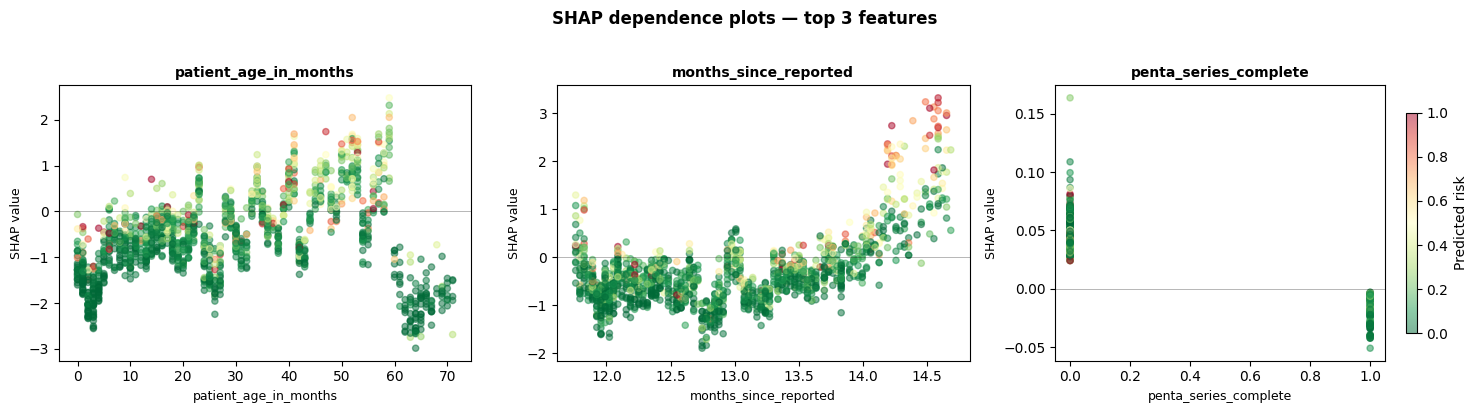

In [12]:
if SHAP_AVAILABLE and shap_vals is not None:
    top3 = shap_imp["feature"].head(3).tolist()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, feat in zip(axes, top3):
        if feat in feature_names:
            feat_idx = feature_names.index(feat)
            feat_vals = X_test_t[:, feat_idx]
            sv = shap_vals[:, feat_idx]
            sc = ax.scatter(feat_vals, sv, c=y_prob, cmap="RdYlGn_r",
                            alpha=0.5, s=20, vmin=0, vmax=1)
            ax.set_xlabel(feat, fontsize=9)
            ax.set_ylabel("SHAP value", fontsize=9)
            ax.set_title(feat, fontsize=10, fontweight="bold")
            ax.axhline(0, color="black", linewidth=0.5, alpha=0.4)

    plt.colorbar(sc, ax=axes[-1], label="Predicted risk", shrink=0.8)
    plt.suptitle("SHAP dependence plots — top 3 features",
                 fontsize=12, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    bar_path = SHAP_DIR / "shap_bar.png"
    if bar_path.exists():
        print("Displaying saved SHAP bar chart from last production run:")
        display(Image(filename=str(bar_path), width=700))

## 7. Saved production report images

Production SHAP artifacts in reports/shap/:
  shap_bar.png


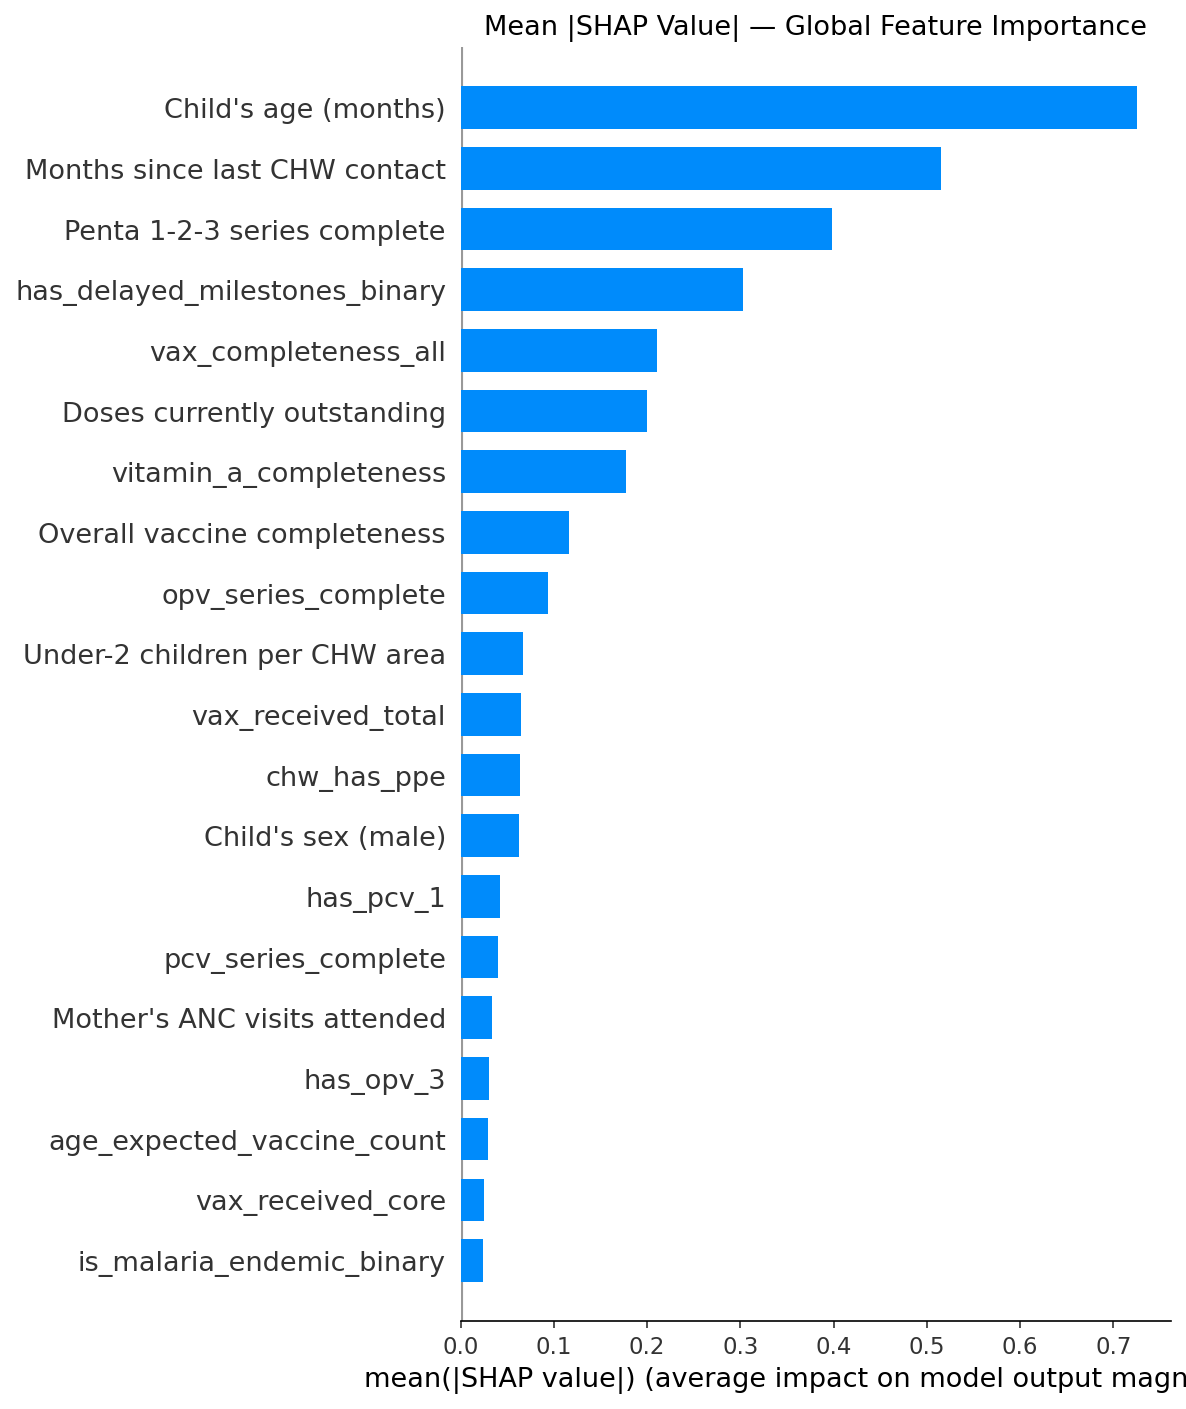

  shap_beeswarm.png


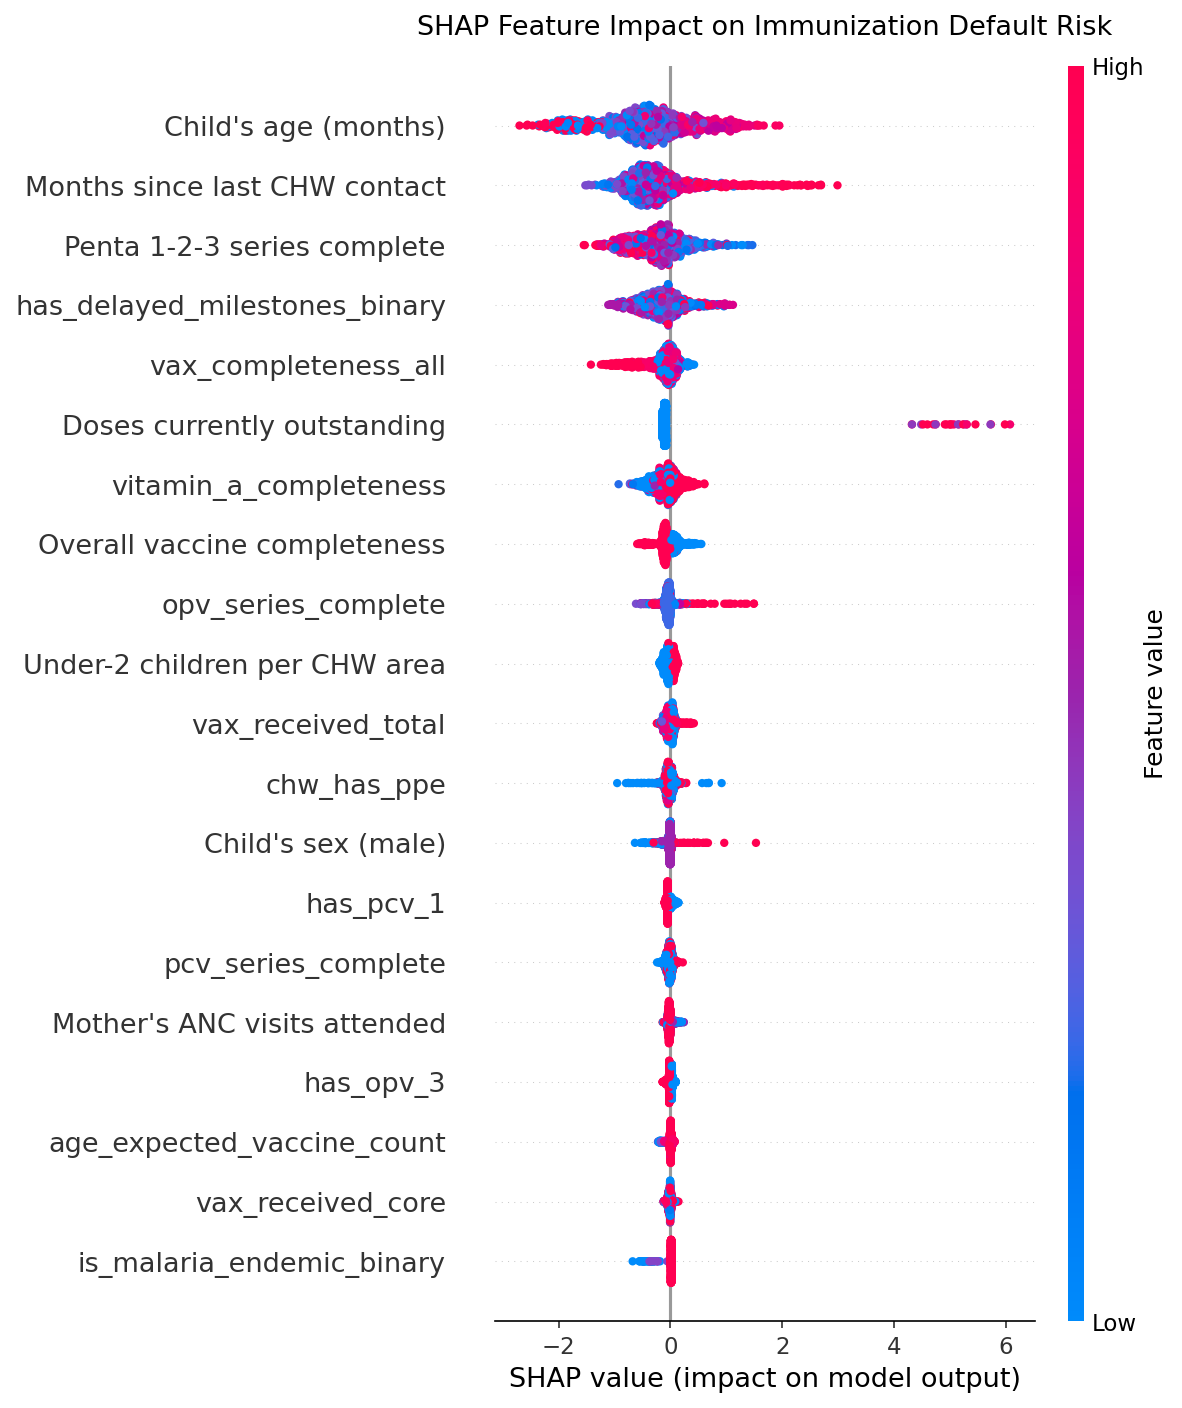

  waterfall_high_example.png


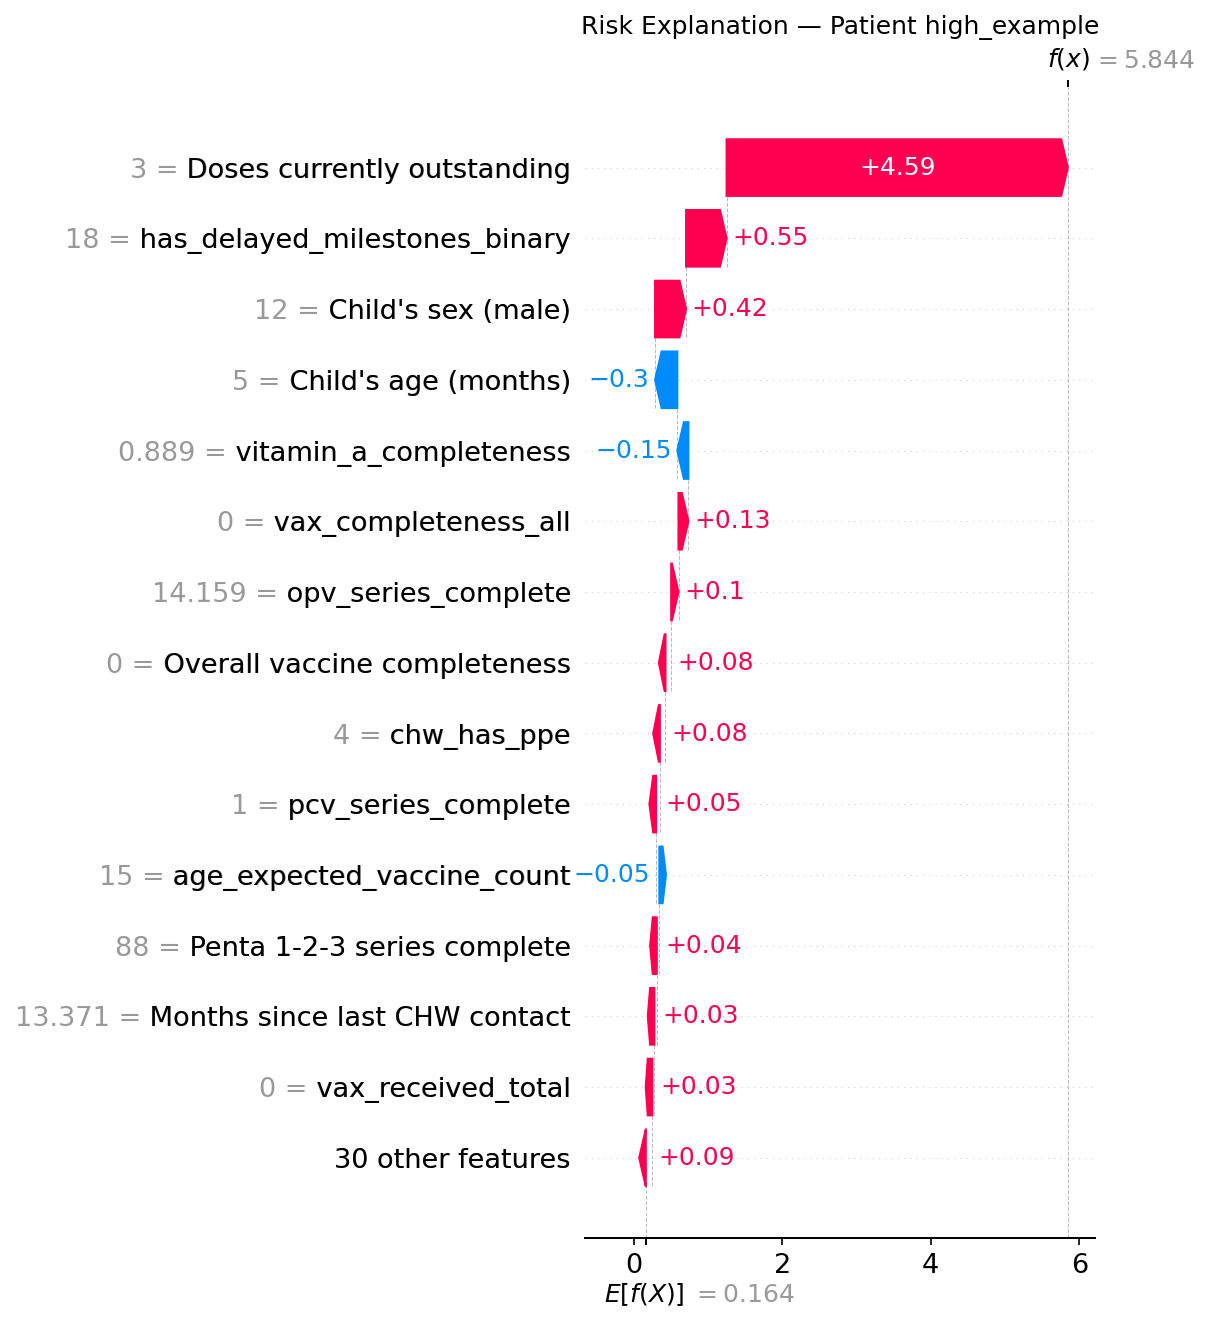

  waterfall_low_example.png


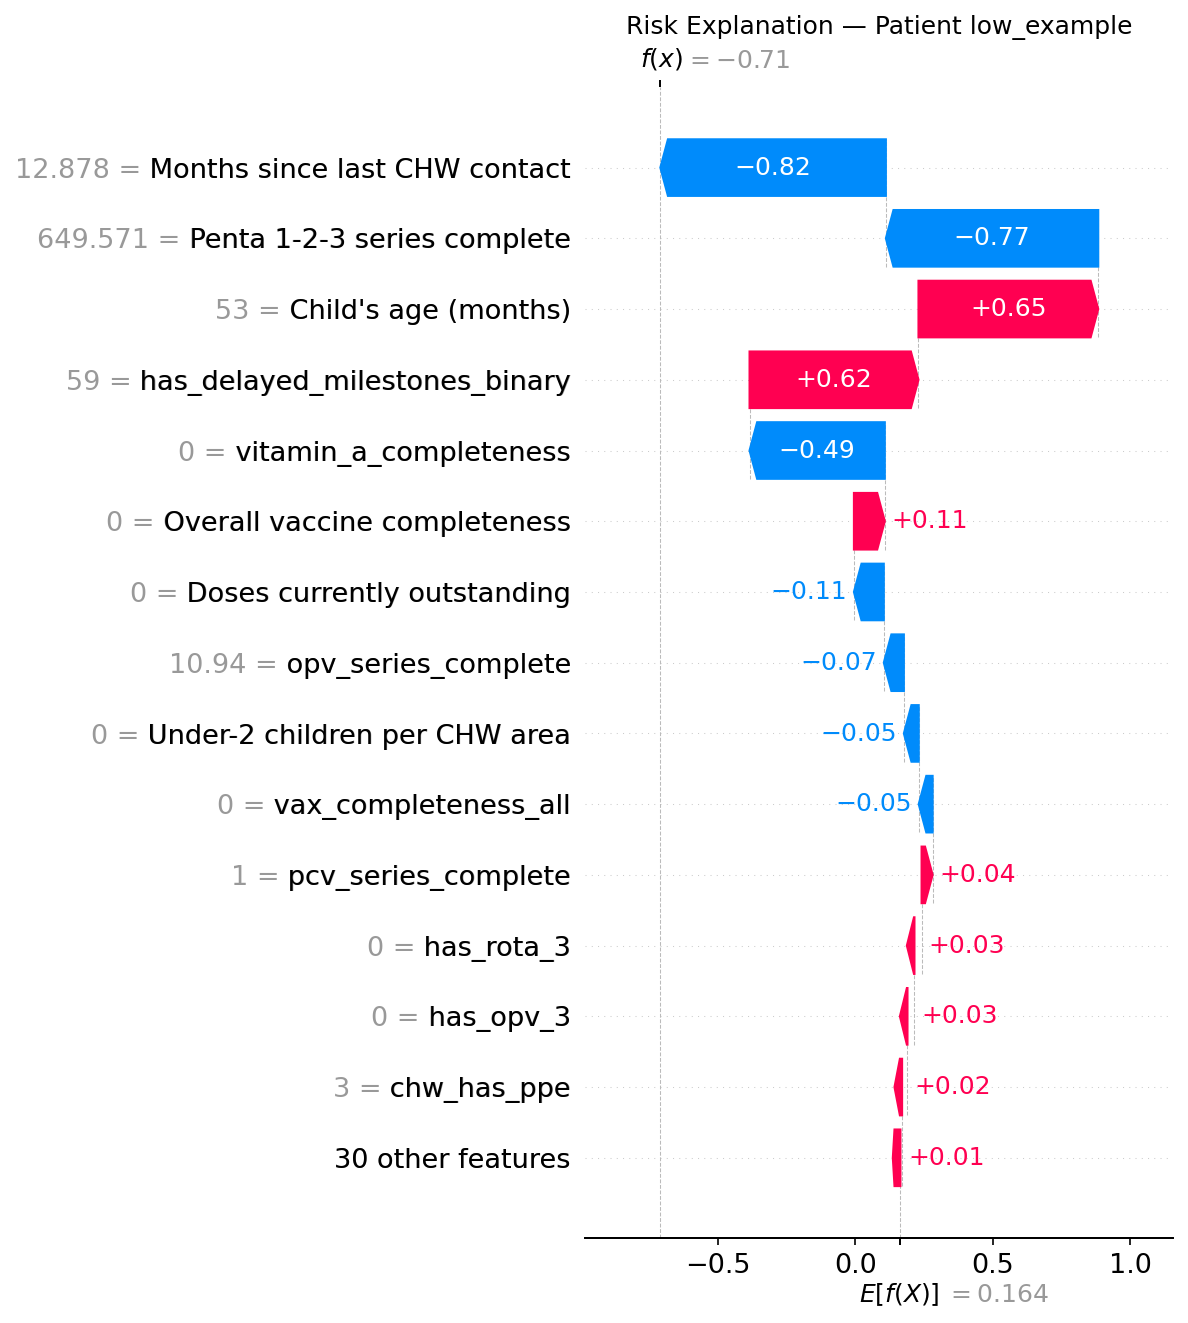

  waterfall_medium_example.png


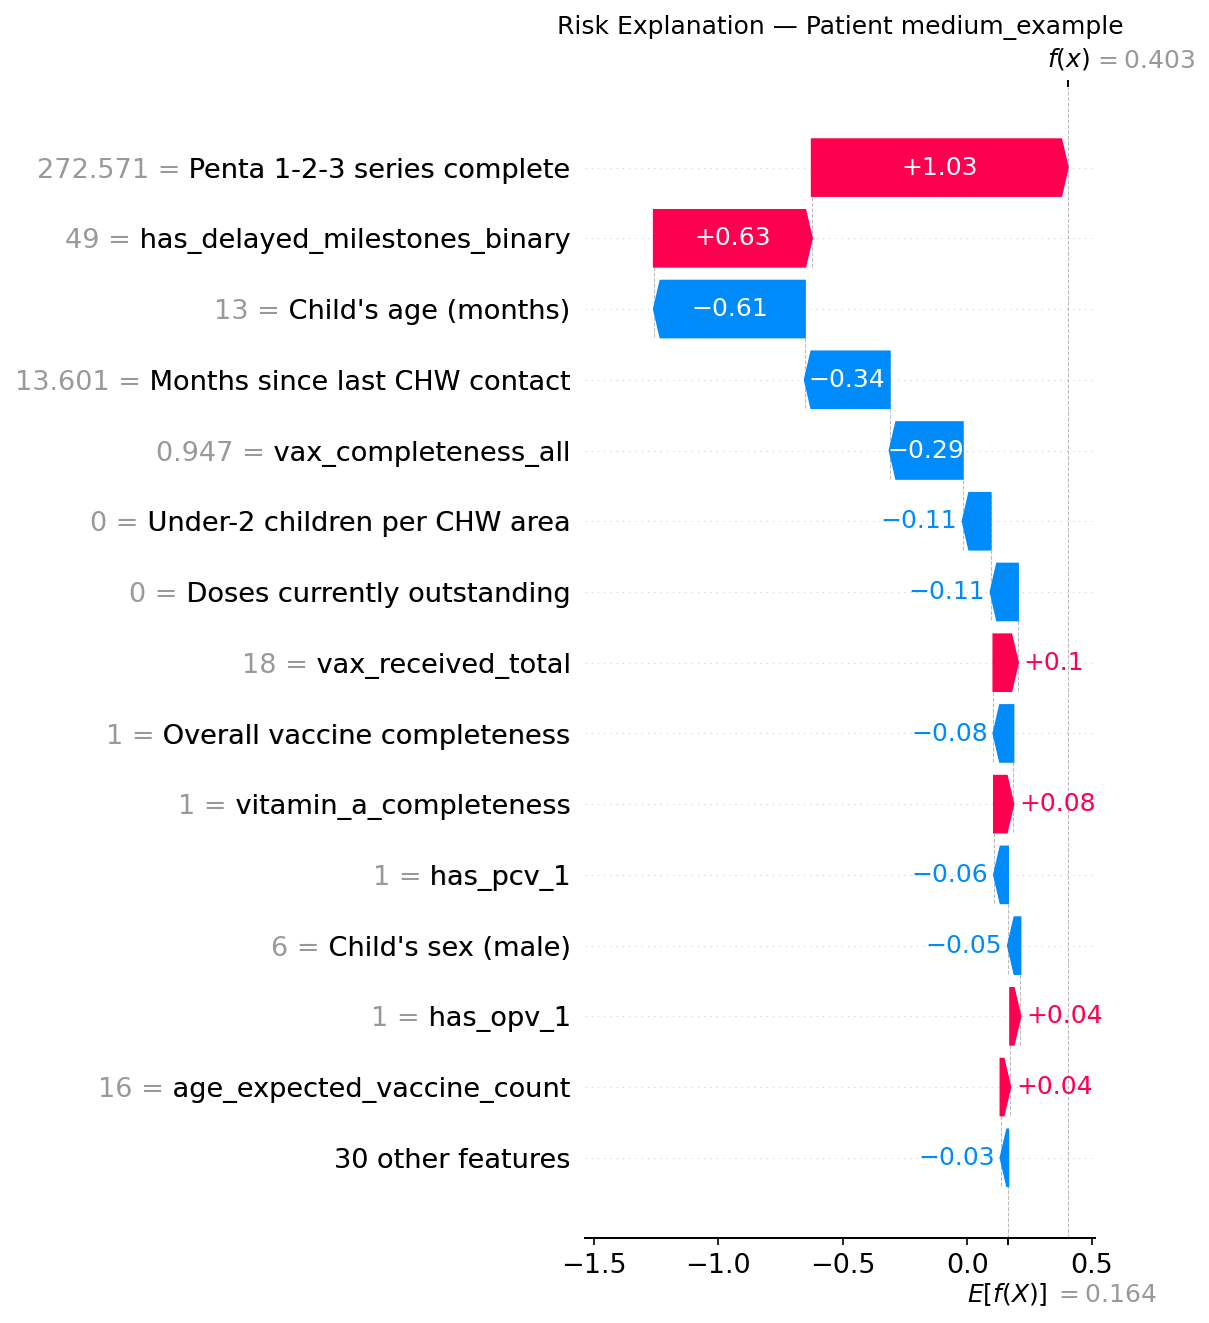

In [13]:
print("Production SHAP artifacts in reports/shap/:")
for path in sorted(SHAP_DIR.glob("*.png")):
    print(f"  {path.name}")
    display(Image(filename=str(path), width=750))

## 8. Explainability framework notes

| Aspect | Detail |
|---|---|
| **SHAP method** | `TreeExplainer` — exact (not approximate) for tree-based models; O(TLD²) complexity |
| **Base value** | SHAP values sum to `log_odds(prediction) − log_odds(base_rate)`; additive decomposition |
| **Global view** | Beeswarm: shows both magnitude and direction of effect for each feature; bar: ranks by mean\|SHAP\| |
| **Local view** | Waterfall: shows exactly how each feature pushes a specific child's probability above/below the base rate |
| **Reason codes** | Top-3 SHAP drivers translated to plain-language sentences for CHW mobile app display |
| **Age dominance** | `patient_age_in_months` is the top driver — expected; the vaccine schedule is fully age-determined |
| **CHW context** | `months_since_reported`, `chw_workload_u2`, and supervision features appear in top 10 — system-level factors matter |
| **Maternal gap** | Maternal features (ANC visits, MUAC) are near-zero SHAP due to 100% null in current data — will gain weight once maternal join is resolved |

### CHW-Facing Reason Code Template (Mobile App)

```
Risk Score: 0.82 (HIGH)  
Why this child is flagged:  
  1. Child is 9 months old — Measles-Rubella booster is now due  
  2. Last CHW contact was 6 months ago  
  3. Pentavalent series not yet completed  
Action: Schedule home visit within 7 days
```